# 🚗 Traffic Accident Severity Prediction using Machine Learning

## 📌 Overview

This project focuses on predicting the severity of traffic accidents using machine learning.

Instead of relying only on assumptions, we use data
- Identify key factors contributing to accidents

The system uses a Random Forest model for accurate and reliable predictions.-driven insights to:
- Predict accident severity

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [2]:
df = pd.read_csv("dataset_traffic_accident_prediction1.csv")
df = df.dropna()

df.head()

,Weather,Road_Type,Time_of_Day,Traffic_Density,Speed,Number_of_Vehicles,Driver_Alcohol,Accident_Severity,Road_Condition,Vehicle_Type,Driver_Age,Driver_Experience,Road_Light_Condition
2,Rainy,Highway,Evening,1.0,60.0,4.0,0.0,Low,Icy,Car,54.0,52.0,Artificial Light
3,Clear,City Road,Afternoon,2.0,60.0,3.0,0.0,Low,Under Construction,Bus,34.0,31.0,Daylight
4,Rainy,Highway,Morning,1.0,195.0,11.0,0.0,Low,Dry,Car,62.0,55.0,Artificial Light
6,Foggy,Highway,Afternoon,0.0,60.0,4.0,0.0,Low,Dry,Truck,27.0,26.0,Daylight
7,Rainy,City Road,Afternoon,0.0,60.0,4.0,0.0,Low,Dry,Car,29.0,22.0,Artificial Light


In [3]:
le = LabelEncoder()

categorical_cols = [
    'Weather',
    'Road_Type',
    'Time_of_Day',
    'Road_Condition',
    'Vehicle_Type',
    'Road_Light_Condition',
    'Accident_Severity'
]

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [4]:
# ================================
# Experience Ratio
# ================================
df['Experience_Ratio'] = df['Driver_Experience'] / df['Driver_Age']


# ================================
# Environment Risk (REAL MAPPING)
# ================================

# Weather mapping (based on your dataset)
weather_risk = {
    'Clear': 1,
    'Foggy': 2,
    'Rainy': 3,
    'Stormy': 4,
    'Snowy': 4
}

# Time of Day mapping
time_risk = {
    'Morning': 1,
    'Afternoon': 1,
    'Evening': 2,
    'Night': 3
}

# Road Condition mapping
road_risk = {
    'Dry': 1,
    'Wet': 2,
    'Icy': 3,
    'Under Construction': 3
}


# Create Environment Risk
df['Environment_Risk'] = (
    df['Weather'].map(weather_risk) +
    df['Time_of_Day'].map(time_risk) +
    df['Road_Condition'].map(road_risk)
)

In [5]:
df = df.drop([
    'Weather',
    'Time_of_Day',
    'Road_Condition',
    'Driver_Age',
    'Driver_Experience'
], axis=1)

In [6]:
X = df.drop('Accident_Severity', axis=1)
y = df['Accident_Severity']

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [8]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [9]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.5348837209302325


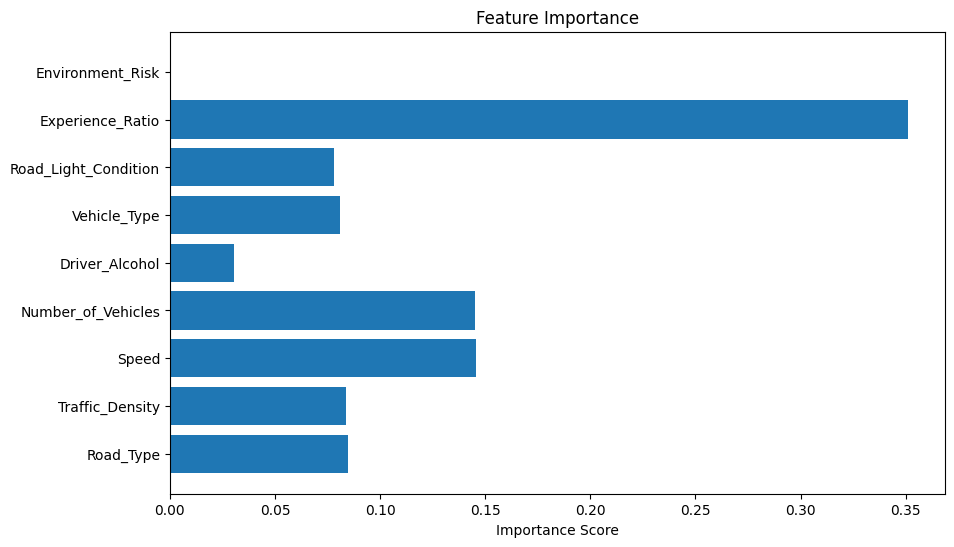

In [10]:
importance = model.feature_importances_
features = X.columns

plt.figure(figsize=(10,6))
plt.barh(features, importance)
plt.xlabel("Importance Score")
plt.title("Feature Importance")
plt.show()

C:\Users\admin\AppData\Local\Temp\ipykernel_7100\3160069132.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Accident_Severity', data=df, palette='Set2')


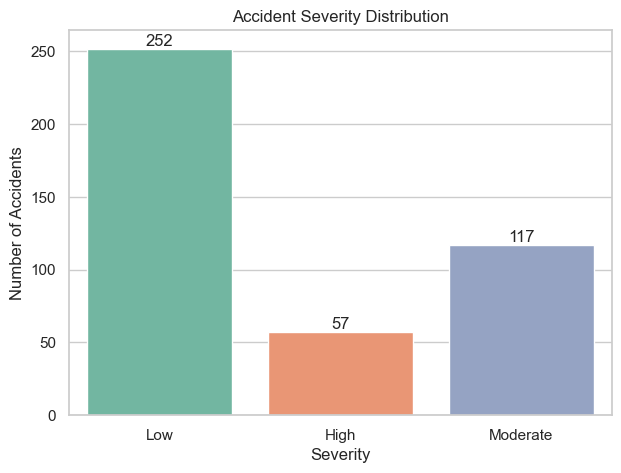

In [8]:


import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")


df = pd.read_csv("dataset_traffic_accident_prediction1.csv")
df = df.dropna()


if df['Accident_Severity'].dtype != 'object':
    df['Accident_Severity'] = df['Accident_Severity'].map({
        0: 'Low',
        1: 'Medium',
        2: 'High'
    })


plt.figure(figsize=(7,5))
ax = sns.countplot(x='Accident_Severity', data=df, palette='Set2')


for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom')

plt.title("Accident Severity Distribution")
plt.xlabel("Severity")
plt.ylabel("Number of Accidents")

plt.show()

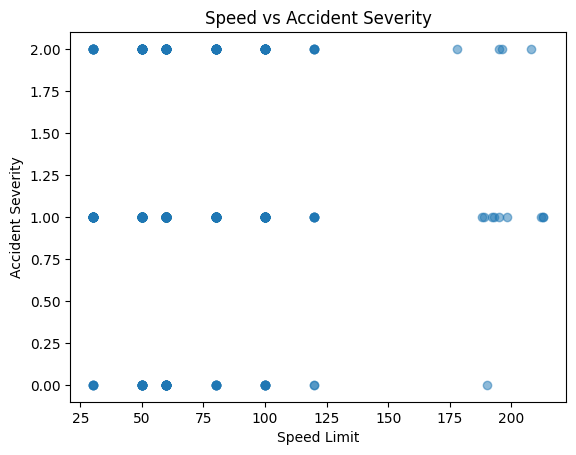

In [ ]:
plt.scatter(df['Speed'], df['Accident_Severity'], alpha=0.5)
plt.xlabel("Speed Limit")
plt.ylabel("Accident Severity")
plt.title("Speed vs Accident Severity")
plt.show() 

In [14]:
sample = X_test.iloc[0].values.reshape(1, -1)
prediction = model.predict(sample)

print("Predicted Severity:", prediction)

Predicted Severity: [1]


c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


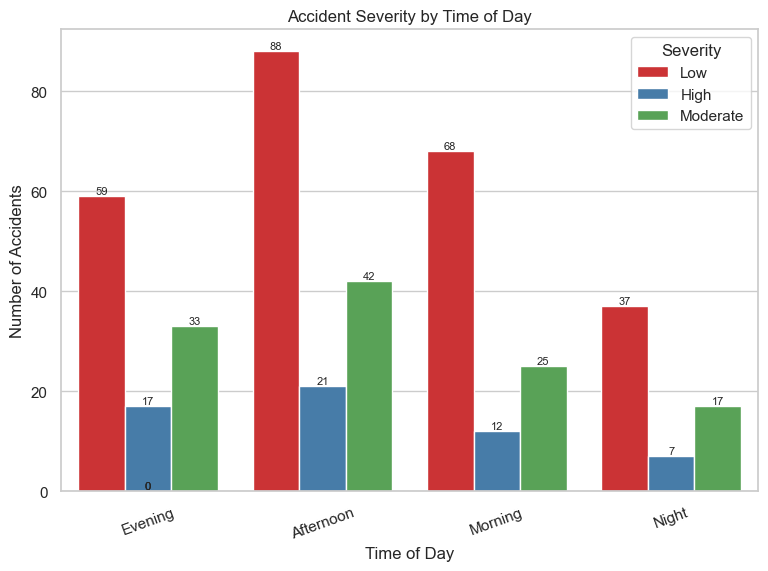

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Load data (if not already loaded)
df = pd.read_csv("dataset_traffic_accident_prediction1.csv")
df = df.dropna()

# Convert severity to labels (if numeric)
if df['Accident_Severity'].dtype != 'object':
    df['Accident_Severity'] = df['Accident_Severity'].map({
        0: 'Low',
        1: 'Medium',
        2: 'High'
    })

# Plot grouped bar chart
plt.figure(figsize=(9,6))
ax = sns.countplot(
    x='Time_of_Day',
    hue='Accident_Severity',
    data=df,
    palette='Set1'
)

# Add counts on bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=8)

plt.title("Accident Severity by Time of Day")
plt.xlabel("Time of Day")
plt.ylabel("Number of Accidents")

plt.legend(title="Severity")
plt.xticks(rotation=20)

plt.show()